In [3]:
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

In [2]:
with open("clip_training.pkl", "rb") as f:
    clip_training = pickle.load(f)

clip_training 

{(128,
  64): {'model_state': OrderedDict([('fc1.weight',
                tensor([[ 4.9529e-02, -2.8452e-01,  3.7582e-02,  ..., -4.5765e-02,
                         -9.5438e-02, -7.8055e-02],
                        [-2.9253e-02, -1.4566e-02, -3.8406e-02,  ..., -3.6163e-02,
                          4.3878e-03, -4.6433e-04],
                        [-1.3510e-02, -2.6850e-02,  1.1402e-02,  ..., -2.9656e-02,
                          8.9585e-03, -9.7214e-03],
                        ...,
                        [ 1.4764e-01,  1.1233e-01,  1.9205e-01,  ...,  2.6413e-02,
                         -1.3561e-02, -2.4813e-02],
                        [-3.0392e-02, -1.2074e-02,  9.7365e-03,  ...,  2.4082e-02,
                          1.6486e-05, -2.5997e-02],
                        [ 8.4927e-03, -1.9335e-01, -2.7009e-01,  ..., -3.3639e-02,
                         -1.5850e-01,  2.9645e-02]], device='cuda:0')),
               ('fc1.bias',
                tensor([-0.0416,  0.0169,  0.0092, -0.0

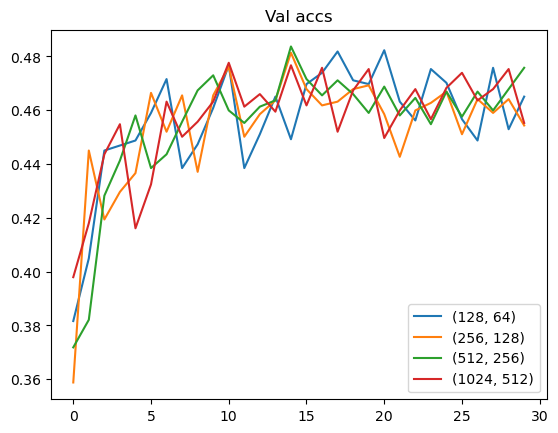

In [5]:
plt.figure()
for params, results in clip_training.items():
    sns.lineplot(results["val_accuracies"], label= f"{params}")
plt.title("Val accs")
plt.show()

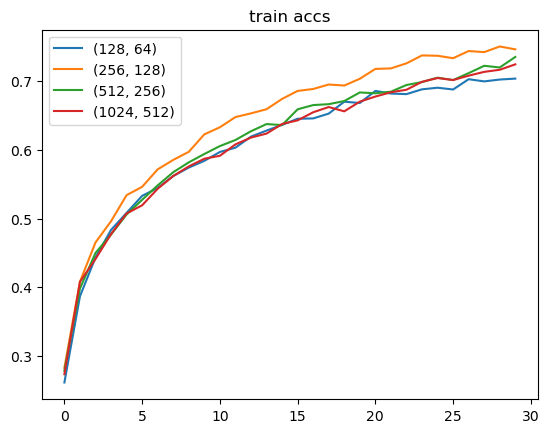

In [6]:
plt.figure()
for params, results in clip_training.items():
    sns.lineplot(results["train_accuracies"], label= f"{params}")
plt.title("train accs")
plt.show()

In [7]:
with open("dino_training.pkl", "rb") as f:
    dino_training = pickle.load(f)

dino_training 

{(128,
  64): {'model_state': OrderedDict([('fc1.weight',
                tensor([[-0.0819, -0.2330, -0.0672,  ...,  0.1096,  0.0448, -0.1963],
                        [ 0.0313,  0.0162, -0.1256,  ..., -0.0295,  0.0228,  0.0156],
                        [-0.0211, -0.0033,  0.0255,  ..., -0.0875,  0.0245, -0.0102],
                        ...,
                        [ 0.0262, -0.0812, -0.0237,  ...,  0.1747,  0.0964,  0.1685],
                        [ 0.0048, -0.0461,  0.0945,  ..., -0.0005,  0.0253,  0.0248],
                        [ 0.1204,  0.1882,  0.0149,  ..., -0.0863,  0.0724,  0.1553]],
                       device='cuda:0')),
               ('fc1.bias',
                tensor([-0.0411, -0.0266,  0.0079, -0.0237, -0.0162, -0.0625,  0.0198, -0.0577,
                        -0.0404, -0.0452, -0.0206, -0.0296, -0.0594, -0.0733, -0.0490, -0.0069,
                         0.0033, -0.0647,  0.0162, -0.0455, -0.0200, -0.0747, -0.0240, -0.0189,
                         0.0170, -0.05

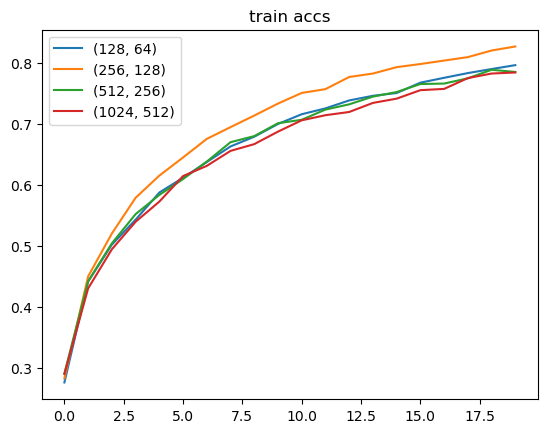

In [9]:
plt.figure()
for params, results in dino_training.items():
    sns.lineplot(results["train_accuracies"], label= f"{params}")
plt.title("train accs")
plt.show()

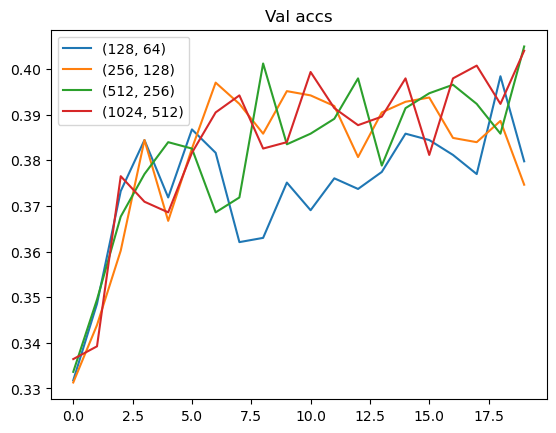

In [10]:
plt.figure()
for params, results in dino_training.items():
    sns.lineplot(results["val_accuracies"], label= f"{params}")
plt.title("Val accs")
plt.show()

In [12]:
# the classifier here is an MLP, but feel free to use something else.
import gdown
import os
import zipfile
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

class dummy_MLP(nn.Module):
    def __init__(self, FM_feature_dim = 32, num_classes = 10, dim1 = 256, dim2 = 256, p = 0.1):
        super().__init__()
        self.fc1 = nn.Linear(FM_feature_dim, dim1) #you can choose your hidden dimensions!
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(dim1, dim2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(dim2, num_classes)
        self.drop1 = nn.Dropout(p)
        self.drop2 = nn.Dropout(p)

    def forward(self, x):
        # x is expected to be the CLIP image features
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.drop1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.drop2(x)
        x = self.fc3(x)
        return x



In [13]:
dino_mlp = dummy_MLP(FM_feature_dim = 768, num_classes = 10, dim1 = 128, dim2 = 64, p = 00)
dino_mlp = dino_mlp.load_state_dict(dino_training[(128,64)]["model_state"])


In [14]:
clip_mlp = dummy_MLP(FM_feature_dim = 768, num_classes = 10, dim1 = 128, dim2 = 64, p = 00)
clip_mlp = clip_mlp.load_state_dict(clip_training[(128,64)]["model_state"])


In [15]:
import torch

cuda_available = torch.cuda.is_available()
mps_available = torch.backends.mps.is_available()  # macOS ARM chips
DEVICE = torch.device("cuda" if cuda_available else ("mps" if mps_available else "cpu"))
print("Using device:", DEVICE)

Using device: cuda


In [19]:
from transformers import CLIPProcessor, CLIPModel
import torch

# Loading CLIP
print("Loading CLIP B32...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32", use_fast=False)
print("CLIP B32 loaded successfully.")

#make sure you freeze the clip model

clip_model.eval()
for param in clip_model.parameters():
    param.requires_grad = False

Loading CLIP B32...


ValueError: Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434

In [ ]:
from transformers import AutoImageProcessor, AutoModel

# Loading DINOv2
print("Loading DINOv2 Base...")
dino_model = AutoModel.from_pretrained("facebook/dinov2-base")
dino_processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
print("DINOv2 Base loaded successfully.")

# Freeze the DINO model
dino_model.eval()
for param in dino_model.parameters():
    param.requires_grad = False

dino_model = dino_model.to(DEVICE)

  Using cached transformers-5.3.0-py3-none-any.whl.metadata (32 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
Using cached transformers-5.3.0-py3-none-any.whl (10.7 MB)
Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl (2.7 MB)
Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl (341 kB)

   -------------------- ------------------- 2/4 [tokenizers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   --------------------------

In [20]:
pip install -U torch torchvision torchaudio

   ---------------------------------------- 0.0/113.7 MB ? eta -:--:--
   - -------------------------------------- 3.1/113.7 MB 15.3 MB/s eta 0:00:08
   -- ------------------------------------- 6.3/113.7 MB 15.4 MB/s eta 0:00:07
   --- ------------------------------------ 9.4/113.7 MB 15.0 MB/s eta 0:00:07
   ---- ----------------------------------- 12.8/113.7 MB 15.2 MB/s eta 0:00:07
   ----- ---------------------------------- 15.7/113.7 MB 15.2 MB/s eta 0:00:07
   ------ --------------------------------- 18.9/113.7 MB 15.1 MB/s eta 0:00:07
   ------- -------------------------------- 22.0/113.7 MB 15.1 MB/s eta 0:00:07
   -------- ------------------------------- 24.9/113.7 MB 14.9 MB/s eta 0:00:06
   --------- ------------------------------ 28.0/113.7 MB 14.8 MB/s eta 0:00:06
   ---------- ----------------------------- 30.9/113.7 MB 14.8 MB/s eta 0:00:06
   ----------- ---------------------------- 34.1/113.7 MB 14.8 MB/s eta 0:00:06
   ------------- -------------------------- 37.2/113